# EDA — Azure Predictive Maintenance

이 노트북은 **탐색 전용**입니다. 여기서 눈으로 확인한 패턴 중 확정된 로직만 나중에 `src/` 아래 `.py`로 옮깁니다.

다루는 데이터: `data/raw/azure_pdm/` — telemetry(센서), errors(경고), maint(정비이력), failures(고장), machines(설비대장).

In [1]:
# 셀 1: 공통 설정 — 한글 폰트, 경로, 라이브러리
# 왜: matplotlib 기본 폰트는 한글을 네모(□)로 깨뜨린다. Windows에 기본 설치된
# 'Malgun Gothic'을 지정해야 그래프 제목·축 라벨의 한글이 정상 출력된다.
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 한글 폰트에서 마이너스 기호가 깨지는 것 방지

# 경로 하드코딩 금지 규칙: 노트북 위치 기준 상대경로로 프로젝트 루트를 찾는다.
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RAW = ROOT / "data" / "raw" / "azure_pdm"
print(f"프로젝트 루트: {ROOT}")
print(f"데이터 폴더: {RAW}")

프로젝트 루트: C:\Users\ansjt\최중호\integrated_dashboard
데이터 폴더: C:\Users\ansjt\최중호\integrated_dashboard\data\raw\azure_pdm


## 1. 4개 테이블 불러오기 — head()와 shape

생산현장 비유: `telemetry`는 센서 로그, `errors`는 알람 이력, `maint`는 정비 일지, `failures`는 고장 신고서다.

In [2]:
telemetry = pd.read_csv(RAW / "PdM_telemetry.csv", parse_dates=["datetime"])
errors = pd.read_csv(RAW / "PdM_errors.csv", parse_dates=["datetime"])
maint = pd.read_csv(RAW / "PdM_maint.csv", parse_dates=["datetime"])
failures = pd.read_csv(RAW / "PdM_failures.csv", parse_dates=["datetime"])
machines = pd.read_csv(RAW / "PdM_machines.csv")

for name, df in [("telemetry", telemetry), ("errors", errors), ("maint", maint), ("failures", failures), ("machines", machines)]:
    print(f"--- {name}: shape={df.shape} ---")
    display(df.head())

--- telemetry: shape=(876100, 6) ---


,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


--- errors: shape=(3919, 3) ---


,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4


--- maint: shape=(3286, 3) ---


,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4


--- failures: shape=(761, 3) ---


,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4


--- machines: shape=(100, 3) ---


,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2


**해석**: `telemetry`는 100대 설비 × 시간별 4종 센서값이라 행수가 압도적으로 많다(876,100행).
반면 `failures`(761건)와 `maint`(3,286건)는 '사건'이 실제로 일어난 순간만 기록되어 있어 훨씬 적다.
이 비대칭이 STEP 3(MTBF/MTTR)에서 '고장이 1회뿐인 설비는 계산 불가'가 생기는 근본 원인이다.

## 2. 설비 1대, 1개월치 센서 시계열

machineID=1, 2015년 1월 한 달치 volt/rotate/pressure/vibration을 그린다.

machineID=1, 2015-01 구간 행수: 738


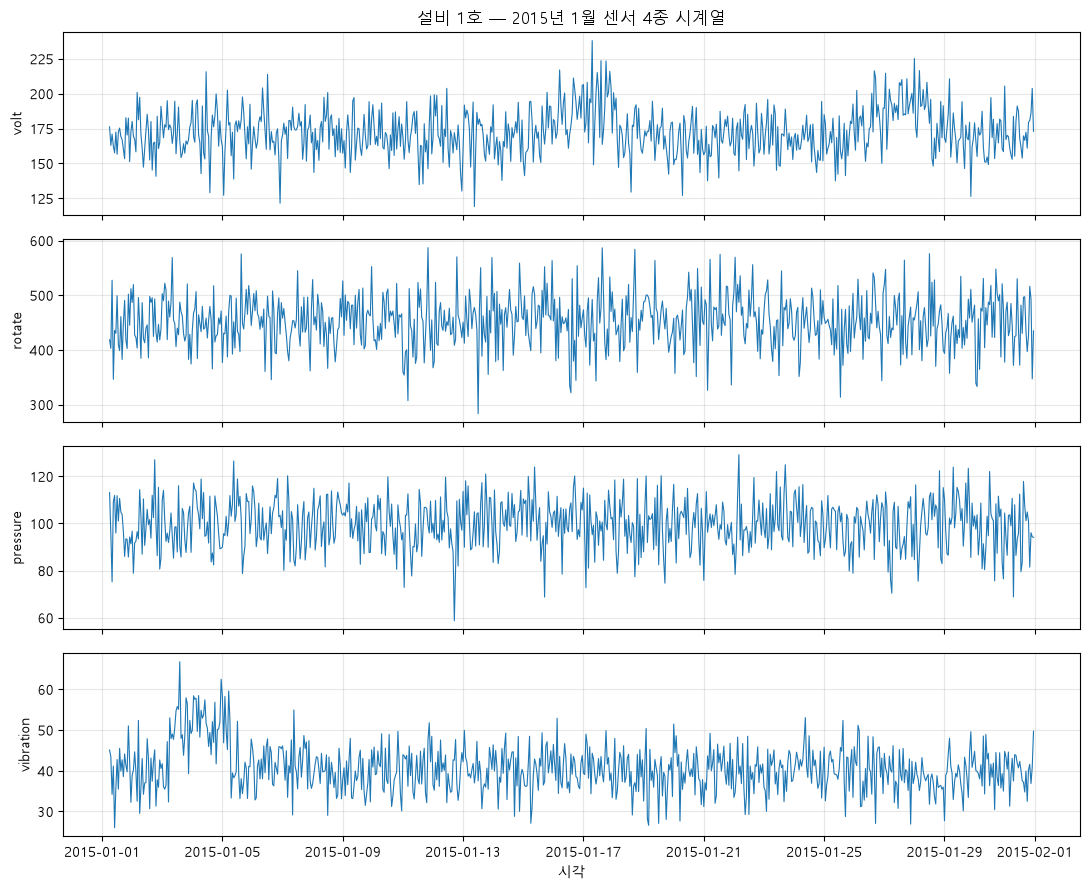

In [3]:
one_machine = telemetry[(telemetry["machineID"] == 1) & (telemetry["datetime"] < "2015-02-01")]
print(f"machineID=1, 2015-01 구간 행수: {len(one_machine)}")

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
sensors = ["volt", "rotate", "pressure", "vibration"]
for ax, sensor in zip(axes, sensors):
    ax.plot(one_machine["datetime"], one_machine[sensor], linewidth=0.8)
    ax.set_ylabel(sensor)
    ax.grid(alpha=0.3)
axes[0].set_title("설비 1호 — 2015년 1월 센서 4종 시계열")
axes[-1].set_xlabel("시각")
plt.tight_layout()
plt.show()

**해석**: 정상 구간에서는 4개 센서 모두 일정 범위 안에서 진동하듯 오르내린다.
이 '평상시 변동폭'을 기준으로 삼아야, 뒤에서(6번) 고장 직전 이상 신호를 상대적으로 판단할 수 있다.

## 3. 고장 부품별 파레토

어떤 부품(comp1~4)이 전체 고장의 대부분을 차지하는가.

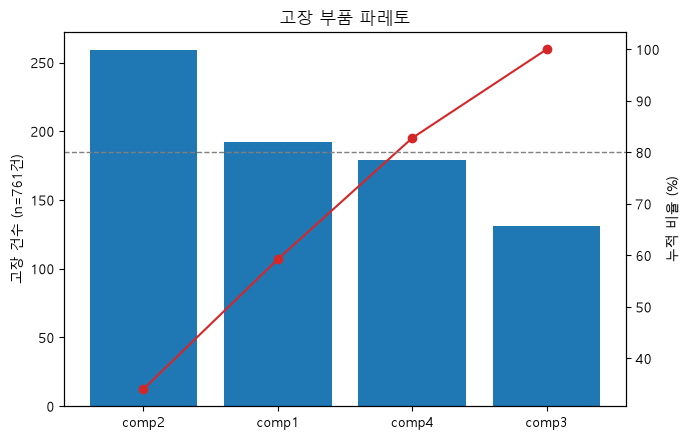

failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64

누적 비율:
failure
comp2     34.0
comp1     59.3
comp4     82.8
comp3    100.0
Name: count, dtype: float64


In [4]:
counts = failures["failure"].value_counts().sort_values(ascending=False)
cum_pct = counts.cumsum() / counts.sum() * 100

fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.bar(counts.index, counts.values, color="#1F77B4")
ax1.set_ylabel("고장 건수 (n=761건)")
ax2 = ax1.twinx()
ax2.plot(counts.index, cum_pct.values, color="#D62728", marker="o")
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("누적 비율 (%)")
ax1.set_title("고장 부품 파레토")
plt.tight_layout()
plt.show()

print(counts)
print(f"\n누적 비율:\n{cum_pct.round(1)}")

**해석**: 실행 결과의 막대 순서와 80% 보조선 교차 지점을 보고, 상위 몇 개 부품이 전체 고장의 80%를 차지하는지
직접 읽는다 — 이 수치가 실제로 몇 %인지는 출력 결과를 봐야 안다(추정 금지).

## 4. 에러코드별 발생 빈도

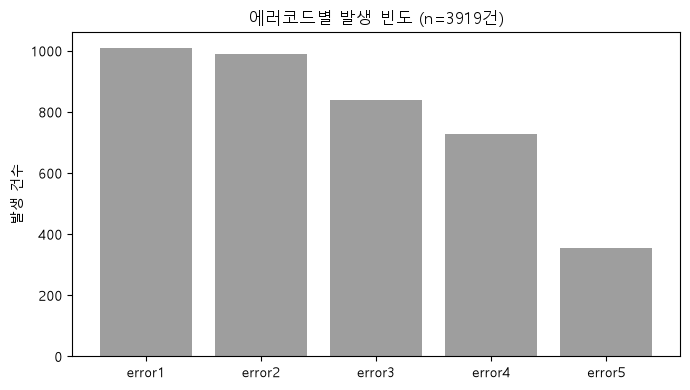

errorID
error1    1010
error2     988
error3     838
error4     727
error5     356
Name: count, dtype: int64


In [5]:
error_counts = errors["errorID"].value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(error_counts.index, error_counts.values, color="#9E9E9E")
ax.set_title(f"에러코드별 발생 빈도 (n={len(errors)}건)")
ax.set_ylabel("발생 건수")
plt.tight_layout()
plt.show()
print(error_counts)

**해석**: `errors`는 고장으로 이어지지 않은 경고까지 포함한다. 특정 에러코드가 유독 잦다면,
그 코드가 실제 고장의 전조인지 아니면 그냥 잡음인지는 `failures`와 시간을 맞춰봐야 알 수 있다(추가 분석 여지).

## 5. 정비 이력 — 계획정비 vs 고장 후 교체

`maint`에는 '왜 교체했는지' 플래그가 없다. 대신 같은 machineID·같은 부품(comp)에 대해
`failures`와 날짜가 겹치는 `maint` 기록은 '고장 후 교체'로, 그렇지 않은 기록은 '계획정비'로 근사 추정한다.

**주의**: 이건 정확한 라벨이 아니라 근사 추정이다 — 원본에 이유 컬럼이 없다는 한계를 그대로 남긴다.

In [6]:
failures_key = failures.rename(columns={"failure": "comp"})[["datetime", "machineID", "comp"]].copy()
failures_key["date"] = failures_key["datetime"].dt.date
maint_key = maint.copy()
maint_key["date"] = maint_key["datetime"].dt.date

merged = maint_key.merge(
    failures_key[["machineID", "comp", "date"]],
    on=["machineID", "comp", "date"],
    how="left",
    indicator=True,
)
merged["reason"] = merged["_merge"].map({"both": "고장 후 교체(추정)", "left_only": "계획정비(추정)"})

reason_counts = merged["reason"].value_counts()
print(reason_counts)
print(f"\n전체 정비 {len(merged)}건 중 고장 후 교체로 날짜가 일치하는 비율: {reason_counts.get('고장 후 교체(추정)', 0) / len(merged) * 100:.2f}%")

reason
계획정비(추정)       2543
고장 후 교체(추정)     743
Name: count, dtype: int64

전체 정비 3286건 중 고장 후 교체로 날짜가 일치하는 비율: 22.61%


**해석**: 이 비율이 낮게 나온다면, 대부분의 `maint` 기록이 미리 짜인 계획정비이고, `failures`는 그 계획을
벗어난 예외적 사건이라는 뜻이다. STEP 3에서 MTTR을 계산할 때 이 '날짜 일치' 매칭 방식을 그대로 재사용한다.

## 6. 고장 전후 24시간 센서 변화 — 전조가 보이는가

모든 고장 이벤트에 대해 '고장 직전 24시간'의 센서 평균을, 해당 설비의 '전체 기간 평균'과 비교한다.
차이가 크다면 그 센서가 고장 전조로 쓸 만하다는 뜻이다.

집계에 사용된 고장 이벤트 수: 761건 (전체 761건 중 telemetry 매칭 성공분)


,평상시 평균,고장 직전 24h 평균,변화율(%)
volt,170.778,176.169,3.157
rotate,446.605,417.220,-6.580
pressure,100.859,105.576,4.677
vibration,40.385,42.909,6.251


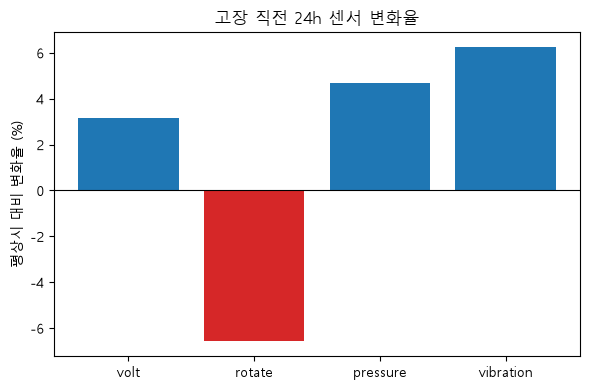

In [8]:
import numpy as np

pre_failure_rows = []
for _, row in failures.iterrows():
    mid, t = row["machineID"], row["datetime"]
    window = telemetry[
        (telemetry["machineID"] == mid)
        & (telemetry["datetime"] < t)
        & (telemetry["datetime"] >= t - pd.Timedelta(hours=24))
    ]
    if len(window) == 0:
        continue
    pre_failure_rows.append(window[sensors].mean())

pre_failure_avg = pd.DataFrame(pre_failure_rows).mean()
overall_avg = telemetry[sensors].mean()

compare = pd.DataFrame({"평상시 평균": overall_avg, "고장 직전 24h 평균": pre_failure_avg})
compare["변화율(%)"] = (compare["고장 직전 24h 평균"] - compare["평상시 평균"]) / compare["평상시 평균"] * 100
print(f"집계에 사용된 고장 이벤트 수: {len(pre_failure_rows)}건 (전체 {len(failures)}건 중 telemetry 매칭 성공분)")
display(compare.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(compare.index, compare["변화율(%)"], color=["#1F77B4" if v >= 0 else "#D62728" for v in compare["변화율(%)"]])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("평상시 대비 변화율 (%)")
ax.set_title("고장 직전 24h 센서 변화율")
plt.tight_layout()
plt.show()

**해석**: 막대가 0에서 멀수록(양수든 음수든) 그 센서가 고장 직전에 평소와 달라진다는 뜻 — 즉 전조 신호 후보다.
정확히 어떤 센서가 얼마나 변했는지는 위 표의 실제 출력값으로 판단한다. 이 결과가 STEP 8(비용민감 모델)에서
'어떤 특징이 고장 예측에 유효한가'를 판단하는 첫 단서가 된다.